In [1]:
import numpy as np
import sympy as sy
import matplotlib.cm as cm
import matplotlib.pylab as plt
from PIL import Image
import warnings
import time
import os

warnings.filterwarnings('ignore')  
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 30
from IPython.display import  display, clear_output, Math

**12.1.1** (Uncoupled linear map)                                                                                                                              
Consider the linear map                                                                                                                                    
$\qquad\qquad\begin{aligned} x_{n+{\tiny 1}}&=ax_n,\\ y_{n+{\tiny 1}}&=by_n, \end{aligned}$                                                                               
where $a,\, b$ are real parameters.                                                                                                                      
Draw all the possible patterns of orbits near the origin, depending on the signs and sizes of $a$ and $b$.

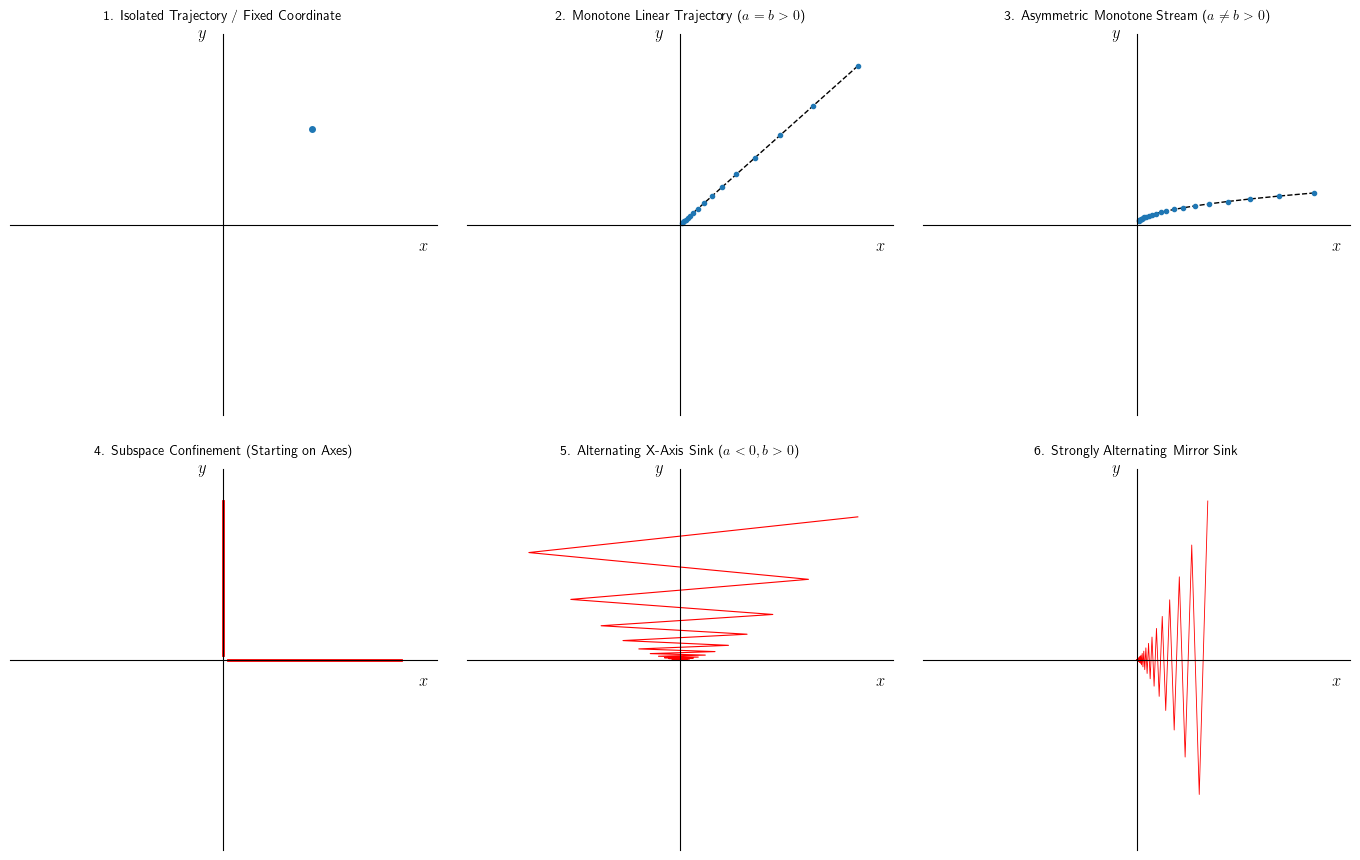

In [7]:
def generate_orbit(x0, y0, a, b, steps=25):
    x, y = [x0], [y0]
    for _ in range(steps):
        x.append(a * x[-1])
        y.append(b * y[-1])
    return np.array(x), np.array(y)

def setup_axis(ax, title_text=""):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')    
    ax.set_xlabel('$x$', loc='right', fontsize=12)
    ax.set_ylabel('$y$', loc='top', fontsize=12, rotation=0)
    ax.xaxis.set_label_coords(0.98, 0.46)
    ax.yaxis.set_label_coords(0.46, 0.98)    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(title_text, fontsize=10, fontweight='bold', pad=10)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
setup_axis(axes[0, 0], "1. Isolated Trajectory / Fixed Coordinate")
axes[0, 0].plot([0.5], [0.6], 'o', markersize=4)

setup_axis(axes[0, 1], "2. Monotone Linear Trajectory ($a = b > 0$)")
x, y = generate_orbit(1.0, 1.0, 0.75, 0.75, steps=15)
axes[0, 1].plot(x, y, 'k--', linewidth=1)
axes[0, 1].plot(x, y, 'o', markersize=3)

setup_axis(axes[0, 2], "3. Asymmetric Monotone Stream ($a \\neq b > 0$)")
x, y = generate_orbit(1.0, 0.2, 0.8, 0.9, steps=20)
axes[0, 2].plot(x, y, 'k--', linewidth=1)
axes[0, 2].plot(x, y, 'o', markersize=3)

setup_axis(axes[1, 0], "4. Subspace Confinement (Starting on Axes)")
x_ax, y_ax = generate_orbit(1.0, 0.0, 0.7, 0.7, steps=10)
axes[1, 0].plot(x_ax, y_ax, 'r-', linewidth=2)
x_ay, y_ay = generate_orbit(0.0, 1.0, 0.7, 0.7, steps=10)
axes[1, 0].plot(x_ay, y_ay, 'r-', linewidth=2)

setup_axis(axes[1, 1], "5. Alternating X-Axis Sink ($a < 0, b > 0$)")
x, y = generate_orbit(1.0, 0.9, -0.85, 0.75, steps=40)
axes[1, 1].plot(x, y, 'r-', linewidth=0.8) # Solid web line matching the manual image sketch

setup_axis(axes[1, 2], "6. Strongly Alternating Mirror Sink")
x, y = generate_orbit(0.4, 1.0, 0.88, -0.85, steps=50)
axes[1, 2].plot(x, y, 'r-', linewidth=0.6)

plt.tight_layout()
plt.show()

**12.1.2** (Stability criterion)                                                                                                                                                                       
Consider the linear map                                                                                                                                    
$\qquad\qquad\begin{aligned} x_{n+{\tiny 1}}&=ax_n + by_n,\\ y_{n+{\tiny 1}}&=cx_n +dy_n, \end{aligned}$                                                                                                                                                                                                        
where $a, b, c, d$ are real parameters.                                                                                                                                    
Find conditions on the parameters which ensure that the origin is globally asymptotically stable,                                                           
i.e., $( x_n, y_n ) \rightarrow ( 0, 0 )$ as $n \rightarrow\infty$, for all initial conditions.

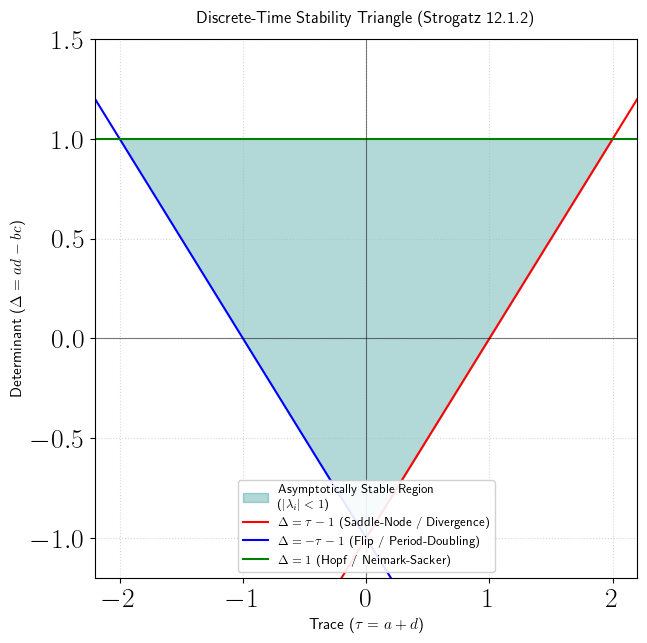

In [3]:
tau = np.linspace(-2.2, 2.2, 500)
line_1 = tau - 1   # Delta = tau - 1
line_2 = -tau - 1  # Delta = -tau - 1
    
plt.figure(figsize=(7, 7))
plt.fill_between(tau, np.maximum(line_1, line_2), 1.0, where=(np.abs(tau) <= 2.0), 
                     color='teal', alpha=0.3, label='Asymptotically Stable Region\n($|\\lambda_i| < 1$)')
plt.plot(tau, line_1, 'r-', linewidth=1.5, label='$\\Delta = \\tau - 1$ (Saddle-Node / Divergence)')
plt.plot(tau, line_2, 'b-', linewidth=1.5, label='$\\Delta = -\\tau - 1$ (Flip / Period-Doubling)')
plt.axhline(1.0, color='g', linestyle='-', linewidth=1.5, label='$\\Delta = 1$ (Hopf / Neimark-Sacker)')
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)
plt.xlim(-2.2, 2.2)
plt.ylim(-1.2, 1.5)
plt.title("Discrete-Time Stability Triangle (Strogatz 12.1.2)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Trace ($\\tau = a + d$)", fontsize=11)
plt.ylabel("Determinant ($\\Delta = ad - bc$)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower center', fontsize=9, framealpha=0.9)
plt.show()

**12.1.3** Sketch the face of Figure 12.1.4 after one more iteration of the baker’s map.

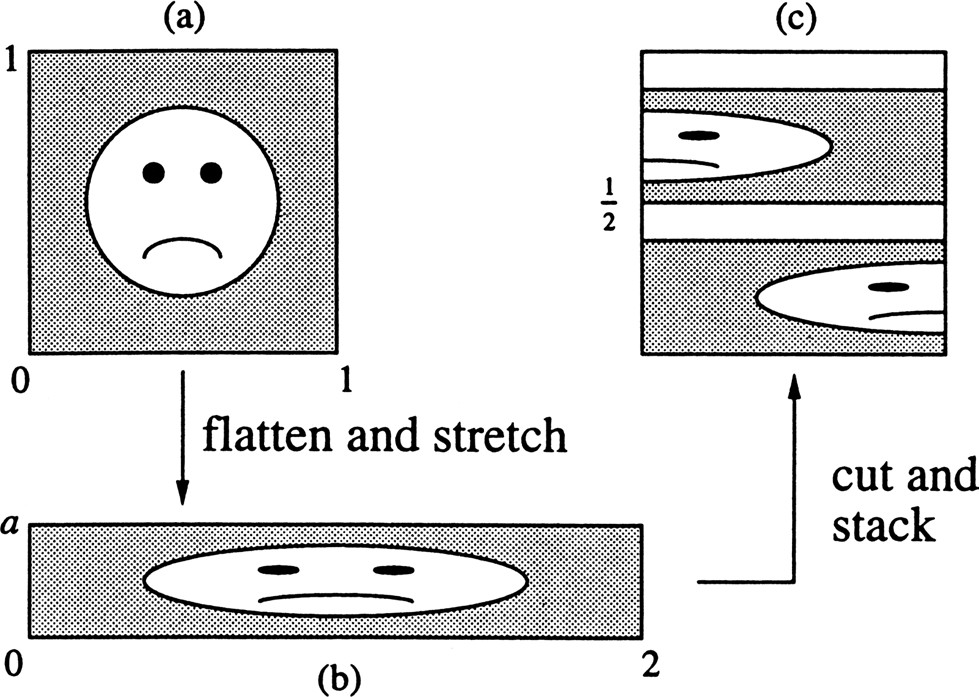

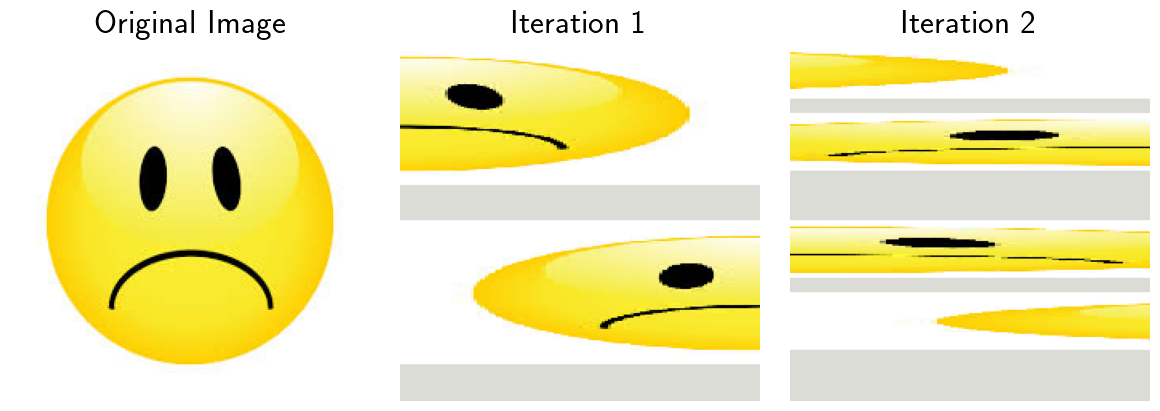

In [6]:
def transform_image_swapped(image_path, a, iterations):
    # Load the image
    image = Image.open(image_path)
    image = image.convert('RGB')  # Ensure the image is in RGB format
    width, height = image.size
    
    # Normalize the pixel coordinates to the unit square
    x_vals, y_vals = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))
    x_vals = x_vals.flatten()
    y_vals = y_vals.flatten()
    
    # Apply the Swapped Baker's Map iterations backward (Inverse Mapping)
    for _ in range(iterations):
        new_x_vals, new_y_vals = [], []
        for x, y in zip(x_vals, y_vals):
            # SWAPPED LOGIC:
            # Lower tier (0 <= y < a) pulls from the RIGHT half of the source
            if 0 <= y < a:
                x_source = (x + 1.0) / 2.0
                y_source = y / a
                new_x_vals.append(x_source)
                new_y_vals.append(y_source)
                
            # Upper tier (0.5 <= y < 0.5 + a) pulls from the LEFT half of the source
            elif 0.5 <= y < (0.5 + a):
                x_source = x / 2.0
                y_source = (y - 0.5) / a
                new_x_vals.append(x_source)
                new_y_vals.append(y_source)
                
            # Gaps / Dissipative empty space
            else:
                new_x_vals.append(-1.0)
                new_y_vals.append(-1.0)
                
        x_vals = np.array(new_x_vals)
        y_vals = np.array(new_y_vals)
    
    # Map the transformed coordinates back to pixel values
    x_vals = (x_vals * (width - 1)).astype(int)
    y_vals = (y_vals * (height - 1)).astype(int)
    
    # Create the transformed image with a light neutral background color
    transformed_image = Image.new('RGB', (width, height), color=(220, 220, 215))
    pixels = transformed_image.load()
    
    original_pixels = image.load()
    for i in range(width):
        for j in range(height):
            idx = j * width + i
            # Paint the pixel only if it lands inside a valid face band strip
            if x_vals[idx] >= 0 and y_vals[idx] >= 0:
                pixels[i, j] = original_pixels[x_vals[idx], y_vals[idx]]
    
    return transformed_image

a = 0.4
iterations =2
image_path = 'sad.jpeg'  # Make sure this matches your yellow emoji file name

# Plot the original and transformed images
fig, axs = plt.subplots(1, iterations+1, figsize=(12, 5))

# Original image
original_image = Image.open(image_path)
axs[0].imshow(original_image)
axs[0].axis('off')
axs[0].set_title('Original Image', fontweight='bold')

# Transformed image panels
for i in range(iterations):
    transformed_image = transform_image_swapped(image_path, a, i+1)
    axs[i+1].imshow(transformed_image)
    axs[i+1].axis('off')
    axs[i+1].set_title(f'Iteration {i+1}', fontweight='bold')

plt.tight_layout()
plt.show()

**12.1.4** (Vertical gaps)                                                                                                                                     
Let $B$ be the baker’s map with $a < \frac12$.                                                                                                                                                                           
Figure 12.1.5 shows that the set $B^2(S)$ consists of horizontal strips separated by vertical gaps of different sizes.                                       
a) Find the size of the largest and smallest gaps in the set $B^2(S)$.                                                                                                                                     
b) Redo part (a) for $B^3(S)$.                                                                                                                                     
c) Finally, answer the question in general for $B^n(S)$.

#### (a) Set $B^2(S)$
After two iterations, the unit square contains 4 horizontal strips of height $a^2$.                                                                     
Ordered from bottom to top, their vertical intervals are:

   1. $[0, a^2]$
   2. $[\frac{a}{2}, \frac{a}{2} + a^2]$
   3. $[\frac{1}{2}, \frac{1}{2} + a^2]$
   4. $[\frac{1}{2} + \frac{a}{2}, \frac{1}{2} + \frac{a}{2} + a^2]$

Calculating the sizes of the vertical gaps between these consecutive strips:

* Smallest Gap (between strips 1 & 2 or 3 & 4):
$$\text{Size} = \frac{a}{2} - a^2 = \mathbf{a\left(\frac{1}{2} - a\right)}$$ 
* Largest Gap (the central void between strips 2 & 3):
$$\text{Size} = \frac{1}{2} - \left(\frac{a}{2} + a^2\right) = \mathbf{\frac{1}{2} - \frac{a}{2} - a^2}$$ 

#### (b) Set $B^3(S)$
After three iterations, the square contains 8 horizontal strips of height $a^3$. Tracking the newly generated gaps:

* Smallest Gap:
$$\text{Size} = \mathbf{a^2\left(\frac{1}{2} - a\right)}$$ 
* Largest Gap (the central void separating the lower 4 and upper 4 strips):
$$\text{Size} = \frac{1}{2} - \left(\frac{a}{2} + \frac{a^2}{2} + a^3\right) = \mathbf{\frac{1}{2} - \frac{a}{2} - \frac{a^2}{2} - a^3}$$ 
  
#### (c)  General Case for $B^n(S)$
By induction, for an arbitrary number of iterations $n$:

* Smallest Gap Size:
$$\text{Smallest Gap} = \mathbf{a^{n-1}\left(\frac{1}{2} - a\right)}$$ 
(As $n \to \infty$, this minimum scale shrinks exponentially to 0).
* Largest Gap Size:
$$\text{Largest Gap} = \mathbf{\frac{1}{2} - \sum_{k=1}^{n-1}\frac{a^k}{2} - a^n}$$ 
Using the geometric series formula $\sum_{k=1}^{n-1} a^k = \frac{a - a^n}{1 - a}$, this can be simplified algebraically to:
$$\text{Largest Gap} = \mathbf{\frac{1}{2}\left[1 - \frac{a - a^n}{1 - a} - 2a^n\right]}$$ 


--- Gap Analysis for B^1(S) with a = 0.35 ---
Total Strips: 2 | Total Gaps: 1
Measured Smallest Gap: 0.150000 | Formula: 0.150000
Measured Largest Gap:  0.150000  | Formula: 0.150000

--- Gap Analysis for B^2(S) with a = 0.35 ---
Total Strips: 4 | Total Gaps: 3
Measured Smallest Gap: 0.052500 | Formula: 0.052500
Measured Largest Gap:  0.202500  | Formula: 0.202500

--- Gap Analysis for B^3(S) with a = 0.35 ---
Total Strips: 8 | Total Gaps: 7
Measured Smallest Gap: 0.018375 | Formula: 0.018375
Measured Largest Gap:  0.220875  | Formula: 0.220875



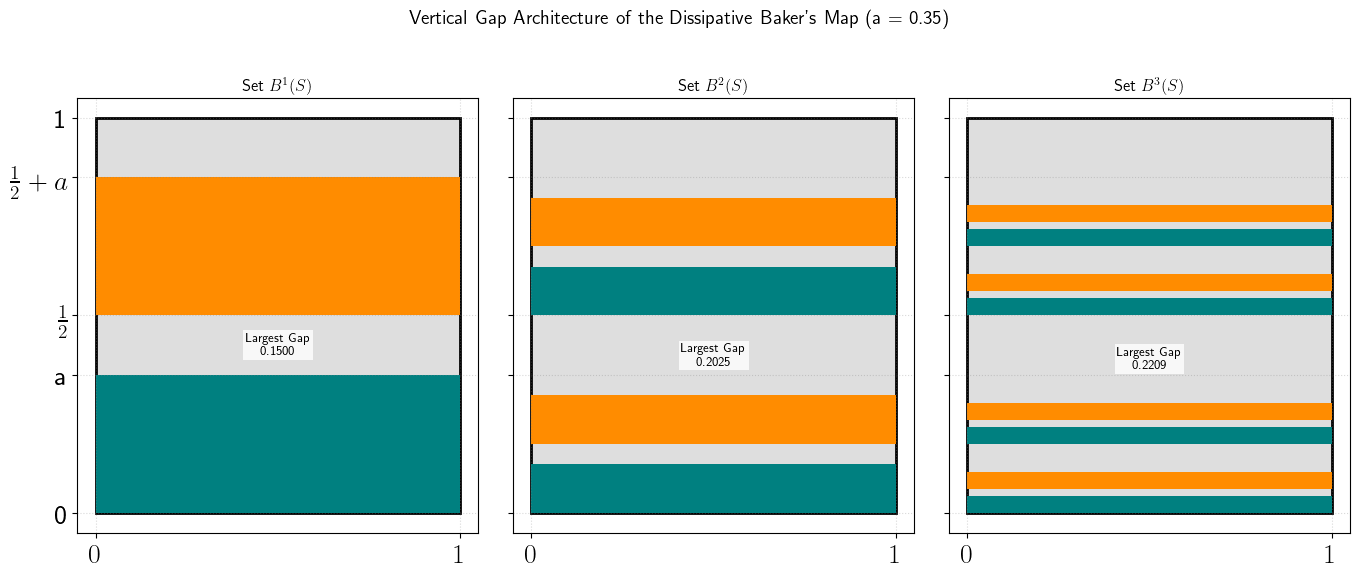

In [15]:
def compute_baker_strips_y(n, a):
    intervals = np.array([[0.0, 1.0]])  
    for _ in range(n):
        next_intervals = []
        for y_min, y_max in intervals:
            # Each strip of height H is compressed to height a*H
            h_new = (y_max - y_min) * a
            
            # The lower branch lands at the bottom tier
            lower_min = y_min * a
            lower_max = lower_min + h_new
            next_intervals.append([lower_min, lower_max])
            
            # The upper branch is shifted up by 0.5
            upper_min = y_min * a + 0.5
            upper_max = upper_min + h_new
            next_intervals.append([upper_min, upper_max])
            
        intervals = np.array(next_intervals)
        
    # Sort the final intervals from bottom to top based on y_min
    intervals = intervals[np.argsort(intervals[:, 0])]
    return intervals

def analyze_gaps(n, a):
    intervals = compute_baker_strips_y(n, a)
    gaps = []
    
    # Calculate the gap between each adjacent pair of strips
    for i in range(len(intervals) - 1):
        gap_size = intervals[i+1, 0] - intervals[i, 1]
        gaps.append(gap_size)
        
    gaps = np.array(gaps)
    measured_smallest = np.min(gaps)
    measured_largest = np.max(gaps)
    
    # Analytical Formulas from Parts (a), (b), (c):
    formula_smallest = (a**(n - 1)) * (0.5 - a)
    
    # Geometric series summation for the largest gap
    geom_sum = sum((a**k) / 2.0 for k in range(1, n))
    formula_largest = 0.5 - geom_sum - (a**n)
    
    print(f"--- Gap Analysis for B^{n}(S) with a = {a} ---")
    print(f"Total Strips: {2**n} | Total Gaps: {2**n - 1}")
    print(f"Measured Smallest Gap: {measured_smallest:.6f} | Formula: {formula_smallest:.6f}")
    print(f"Measured Largest Gap:  {measured_largest:.6f}  | Formula: {formula_largest:.6f}\n")
    
    return intervals, gaps


a_param = 0.35
max_n = 3  # Computes and displays up to B^3(S)
    
fig, axes = plt.subplots(1, max_n, figsize=(14, 6), sharey=True)
    
for n in range(1, max_n + 1):
    ax = axes[n - 1]
    intervals, gaps = analyze_gaps(n, a_param)
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, edgecolor='black', facecolor='#dedede', lw=2, label='Empty Voids'))
    for idx, (y_min, y_max) in enumerate(intervals):
        color = 'teal' if idx % 2 == 0 else 'darkorange'
        ax.add_patch(plt.Rectangle((0, y_min), 1, y_max - y_min, facecolor=color, edgecolor='none'))
    
    mid_idx = (len(intervals) // 2) - 1
    central_gap_y = intervals[mid_idx, 1] + gaps[mid_idx] / 2.0
    ax.text(0.5, central_gap_y, f"Largest Gap\n{gaps[mid_idx]:.4f}", 
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
        
    # Grid and axis styling
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Set $B^{n}(S)$", fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 0.35, 0.5, 0.85, 1.0])
    ax.set_yticklabels(['0', 'a', r'$\frac{1}{2}$', r'$\frac{1}{2}+a$', '1'])
    ax.grid(True, which='both', linestyle=':', alpha=0.3, color='gray')
        
plt.suptitle(f"Vertical Gap Architecture of the Dissipative Baker's Map (a = {a_param})", 
                 fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

**12.1.5** (Area-preserving baker’s map)                                                                                                                   
Consider the dynamics of the baker’s map in the area-preserving case $a=\frac12$.                                                                                                                   
a) Given that $( x, y ) = (a_1\,a_2\,a_3\, \dots , b_1\,b_2\,b_3\,\dots )$ is the binary representation of an arbitrary point in the square, write down the binary representation of $B(x,y)$.                                                                                                                   
(Hint: The answer should look nice.)                                                                                                                            
b) Using part (a) or otherwise, show that $B$ has a period-2 orbit, and sketch its location in the unit square.                                                                                                                   
c) Show that $B$ has countably many periodic orbits.                                                                                                                   
d) Show that $B$ has uncountably many aperiodic orbits.                                                                                                                   
e) Are there any dense orbits? If so, write one down explicitly. If not, explain why not.


a)                                                                                                                                                            
Let $(x, y) = (0.x_1x_2x_3\dots, 0.y_1y_2y_3\dots)$.                                                                                                                                                             
To describe the dynamics more transparently, associate the symbol $\dots y_3y_2y_1 \cdot x_1x_2x_3\dots$ with $(x, y)$ simply by placing $x$ and $y$ back-to-back.                                                                                                                                                             
Then $B(x, y) = \dots y_2y_1x_1 \cdot x_2x_3x_4\dots$. In this notation, in other words, $B$ just shifts the binary point one place to the right.

b)                                                                                                                                                            
In the notation above, $\dots1010.1010\dots$ and $\dots0101.0101\dots$ are the only period-2 points.                                                                                                                                                            
They correspond to $(\frac{2}{3}, \frac{1}{3})$ and $(\frac{1}{3}, \frac{2}{3})$.  

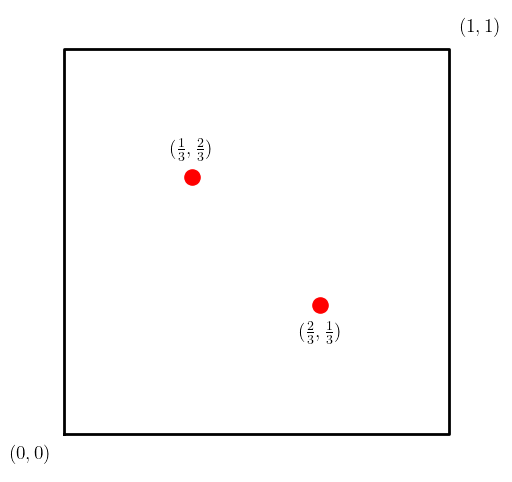

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
square_x = [0, 1, 1, 0, 0]
square_y = [0, 0, 1, 1, 0]
ax.plot(square_x, square_y, color='black', lw=2)
points_x = [1/3, 2/3]
points_y = [2/3, 1/3]
ax.scatter(points_x, points_y, color='red', s=120, zorder=5)
ax.text(1/3, 2/3 + 0.04, r'$(\frac{1}{3}, \frac{2}{3})$', fontsize=14, ha='center', va='bottom')
ax.text(2/3, 1/3 - 0.04, r'$(\frac{2}{3}, \frac{1}{3})$', fontsize=14, ha='center', va='top')
ax.text(-0.03, -0.03, '$(0,0)$', fontsize=14, ha='right', va='top')
ax.text(1.03, 1.03, '$(1,1)$', fontsize=14, ha='left', va='bottom')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

c)                                                                                                                                                            
The points with periodic orbits are when $x$ is a repeating rational number and the digits of $y$ are in the reverse order of $x$.                                                                                                                                                            
$$x = .\overline{a_1a_2\dots a_n} \iff y = .\overline{a_n\dots a_2a_1}$$ 
$$(x,y) = \dots a_n\dots a_2a_1 \cdot a_1a_2\dots a_n\dots$$                                                                                                                                                             
There is a countable number of repeating binary numbers, so there is a countable number of periodic orbits for the baker's map.

d)                                                                                                                                                            
Pick $x = \text{irrational}$ and $y = \text{anything}$.                                                                                                                                                             
The orbit will never repeat because irrationals never repeat.                                                                                                                                                             
There is an uncountable number of irrational numbers, so there is an uncountable number of aperiodic orbits.

e)                                                                                                                                                            
There are dense orbits.                                                                                                                                                             
The plan will be to fill out a grid of points where the coordinates are integer multiples of $2^0$, then $2^{-1}$, then $2^{-2}$, then $2^{-3}, \dots$
                                                   

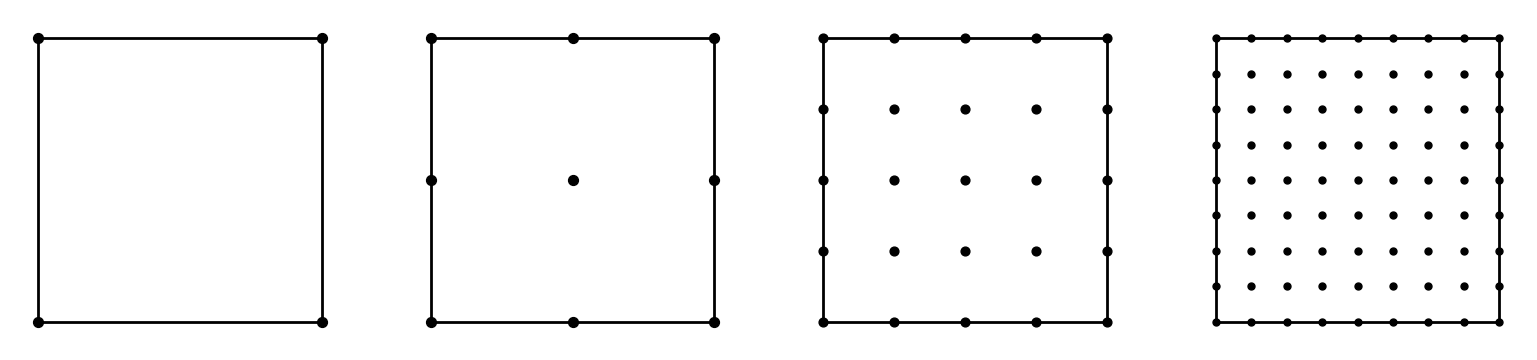

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, ax in enumerate(axes):
    ax.set_aspect('equal')
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='black', linewidth=2)
    
    if i == 0:
        x, y = np.meshgrid(np.linspace(0, 1, 2), np.linspace(0, 1, 2))
        x = x.flatten()
        y = y.flatten()
        mask = (x == 0) | (x == 1) | (y == 0) | (y == 1)
        ax.scatter(x[mask], y[mask], color='black', s=50, zorder=3)
        
    elif i == 1:
        x, y = np.meshgrid(np.linspace(0, 1, 3), np.linspace(0, 1, 3))
        ax.scatter(x, y, color='black', s=50, zorder=3)
        
    elif i == 2:
        x, y = np.meshgrid(np.linspace(0, 1, 5), np.linspace(0, 1, 5))
        ax.scatter(x, y, color='black', s=40, zorder=3)
        
    elif i == 3:
        x, y = np.meshgrid(np.linspace(0, 1, 9), np.linspace(0, 1, 9))
        ax.scatter(x, y, color='black', s=25, zorder=3)
    
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.axis('off')
plt.tight_layout()
plt.show()

Next, we will need some notation. Let $p$ and $q$ be sequences of $0$s and $1$s.                                                                            
A point in the unit square can be represented by $(0.p, 0.q)$ for some sequences $p$ and $q$.                                                                 
Let $\tilde{q}$ denote the reverse sequence of $q$.
Now, take all the points in the first grid (shown in part e) and find their binary representations:
$$(0.p_1^1, 0.q_1^1), \quad (0.p_2^1, 0.q_2^1), \quad (0.p_3^1, 0.q_3^1), \quad \text{and} \quad (0.p_4^1, 0.q_4^1)$$ 
We construct the initial segment of $x$ by concatenating these sequences back-to-back:
$$x = 0.\tilde{q}_1^1 p_1^1 \tilde{q}_2^1 p_2^1 \tilde{q}_3^1 p_3^1 \tilde{q}_4^1 p_4^1 \dots$$ 
Next, take all the points in the second grid and find their binary representations:
$$(0.p_1^2, 0.q_1^2), \quad (0.p_2^2, 0.q_2^2), \quad \dots, \quad (0.p_9^2, 0.q_9^2)$$ 
Append these to $x$ following the exact same pattern:
$$x = 0.\tilde{q}_1^1 p_1^1 \dots \tilde{q}_4^1 p_4^1 \tilde{q}_1^2 p_1^2 \dots \tilde{q}_9^2 p_9^2 \dots$$ 
Repeat this process inductively for all subsequent grids.                                                                                                     
By setting $y = 0$, we establish a point $(x, y) = (x, 0)$ that possesses a dense orbit.                                                                    
Applying the baker’s map $B$ a sufficient number of times ($n$ times) shifts the binary point to the right, yielding:
$$B^n(x, 0) = \dots \tilde{q}_i^j \cdot p_i^j \dots = (0.p_i^j \dots, 0.q_i^j \dots)$$ 
This operation will successfully recover any target grid point $(0.p_i^j, 0.q_i^j)$,                                                                          
accompanied only by trailing "junk" digits further down the binary representation.                                                                              
Since the maximum distance between adjacent grid points approaches zero as the grid refinement goes to infinity,                                             
this single orbit will eventually pass arbitrarily close to any specified point within the unit square in a finite number of steps.                      
Therefore, the orbit is dense.

## $\qquad\qquad\qquad\qquad\qquad\qquad\qquad\text{The Smale horseshoe map}$
Let
$$Q = [-1,1] \times [-1,1] \subset \mathbb{R}^{2}$$ 
be the initial square in phase space. A single iteration of the horseshoe transformation is constructed as the composition of two mappings,
$$H = F \circ L,$$ 
where L is a linear affine deformation and F is a nonlinear folding transformation.
## Linear Stretching
The first stage consists of anisotropic expansion and contraction.                                                                                          
The square is stretched along the horizontal direction while being compressed vertically. The affine transformation is defined as:
$$L(\mathbf{x}) = \mathbf{A}(\mathbf{x}-\mathbf{p}) + \mathbf{p},$$ 
where
$$\mathbf{x} = \begin{pmatrix} x \\ y \end{pmatrix}, \qquad \mathbf{p} = \begin{pmatrix} -1 \\ -1 \end{pmatrix},$$ 
and
$$\mathbf{A} = \begin{pmatrix} 2.5 & 0 \\ 0 & 0.4 \end{pmatrix}.$$ 
Evaluating this system yields the intermediate coordinate expressions:
$$\begin{aligned} x' &= 2.5(x+1) - 1, \\ y' &= 0.4(y+1) - 1. \end{aligned}$$ 
The determinant of the transformation matrix is:
$$\det(\mathbf A) = 2.5 \times 0.4 = 1,$$ 
which proves that the mapping is strictly area-preserving while producing exponential expansion along one principal direction and contraction along the other.
## Nonlinear Folding
The elongated strip cannot remain unbounded within physical phase space and must be folded back into the original neighborhood.                          
The folding map **F** is defined piecewise according to the stretched horizontal coordinate domains.                                                           
For the regional band $1 ≤ x' < 2$, a semicircular rotation parameter is introduced:
$$\theta = \pi(x'-1),$$ 
yielding the nonlinear transformation:
$$\begin{aligned} x'' &= 1 - y'\sin\theta, \\ y'' &= y'\cos\theta. \end{aligned}$$ 
This coordinate assignment smoothly bends the stretched strip through an angular trajectory varying continuously across $0 ≤ θ ≤ π$.                              
For the terminal overflow region x' ≥ 2, the remaining portion undergoes a rigid 180° inversion coupled with a translation shift:
$$\begin{aligned} x'' &= 3 - x', \\ y'' &= -y'. \end{aligned}$$ 
Consequently, the complete non-linear folding function F(x', y') is expressed as:
$$F(x',y') = \begin{cases} (x',y'), & x' < 1, \\ \left(1 - y'\sin\theta, \, y'\cos\theta\right), & 1 \le x' < 2, \\ (3 - x', -y'), & x' \ge 2. \end{cases}$$ 
## Horseshoe Transformation
The complete forward transformation map is the composite system:
$$H(x,y) = F\left(L(x,y)\right).$$ 
Repeated discrete applications produce the trajectory sequence:
$$(x_n,y_n) = H^n(x_0,y_0),$$ 
where $H^n$ denotes the n-th iteration layer:
$$H^n = \underbrace{H \circ H \circ \cdots \circ H}_{n \text{ times}}.$$ 
Each forward iteration step stretches trajectories exponentially along the unstable manifold, contracts them along the stable manifold,                         
and folds the resulting strip back into the bounded domain Q.                                                                                             
This structural recurrence isolates the invariant Cantor set attractor $\Lambda$,                                                                     
generating key topological signatures of chaos including sensitive dependence on initial conditions,                                                    
structural mixing, and an infinite set of unstable periodic orbits.



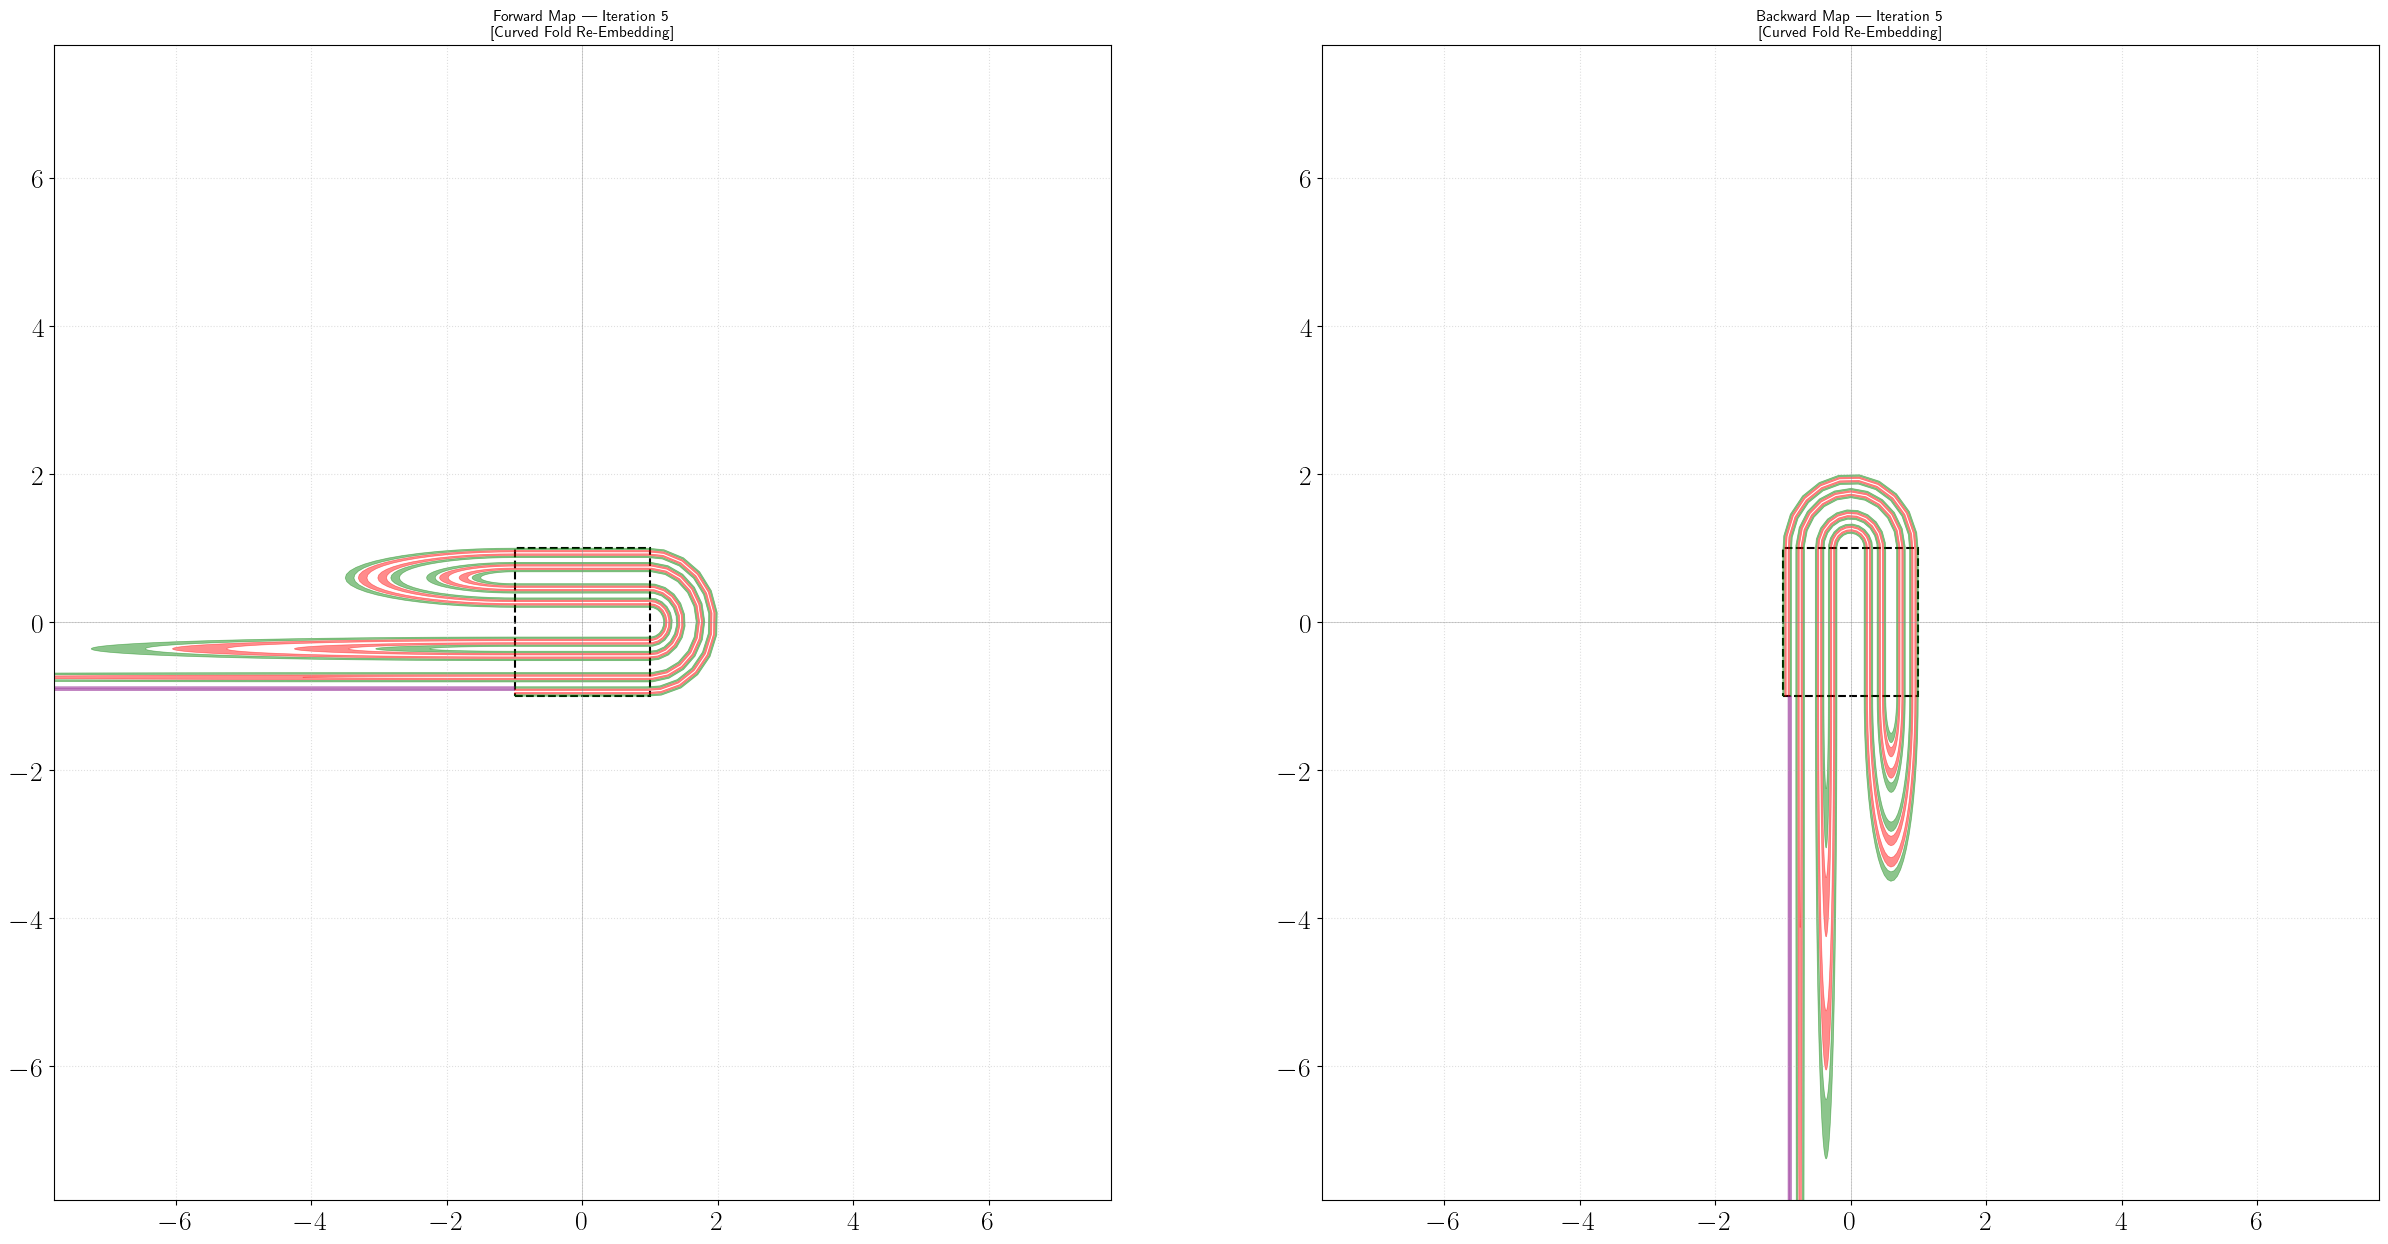

In [2]:
def create_points(a, b, c, d, n=800):
    side1 = np.linspace(a, b, n)
    side2 = np.linspace(b, c, n)
    side3 = np.linspace(c, d, n)
    side4 = np.linspace(d, a, n)
    pts = np.vstack([side1, side2, side3, side4])
    return pts[:, 0], pts[:, 1]

def apply_linear_stretch(x, y, matrix, about_point=None):
    if about_point is None:
        about_point = np.array([-1.0, -1.0])
    x_shifted = x - about_point[0]
    y_shifted = y - about_point[1]
    x_new = matrix[0][0] * x_shifted + matrix[0][1] * y_shifted + about_point[0]
    y_new = matrix[1][0] * x_shifted + matrix[1][1] * y_shifted + about_point[1]
    return x_new, y_new

def f_map_to_circle(x, y):
    x_out, y_out = np.copy(x), np.copy(y)
    mask_circle = (x >= 1.0) & (x < 2.0)      # Semicircular bending zone [1, 2)
    x_c = x[mask_circle] - 1.0
    x_out[mask_circle] = (-np.sin(np.pi * x_c) * y[mask_circle]) + 1.0
    y_out[mask_circle] = np.cos(np.pi * x_c) * y[mask_circle]
    mask_trans = x >= 2.0                        # Linear translation and 180 flip zone [2, infinity)
    x_out[mask_trans] = (-x[mask_trans]) + 3.0
    y_out[mask_trans] = -y[mask_trans]  
    return x_out, y_out

def b_map_to_circle(x, y):
    x_out, y_out = np.copy(x), np.copy(y)
    y_inv, x_inv = np.copy(x), np.copy(y) # Swapped to reuse core logic
    
    mask_circle = (x_inv >= 1.0) & (x_inv < 2.0)
    x_c = x_inv[mask_circle] - 1.0
    y_out[mask_circle] = (-np.sin(np.pi * x_c) * y_inv[mask_circle]) + 1.0
    x_out[mask_circle] = np.cos(np.pi * x_c) * y_inv[mask_circle]
    
    mask_trans = x_inv >= 2.0
    y_out[mask_trans] = (-x_inv[mask_trans]) + 3.0
    x_out[mask_trans] = -y_inv[mask_trans]
    
    return x_out, y_out

def execute_full_forward_step(strips):
    f_matrix = [[2.5, 0.0], [0.0, 0.4]]
    anchor = np.array([-1.0, -1.0])
    next_generation = []
    for x, y, color in strips:
        sx, sy = apply_linear_stretch(x, y, f_matrix, about_point=anchor)
        fx, fy = f_map_to_circle(sx, sy)
        next_generation.append([fx, fy, color])
    return next_generation

def execute_full_backward_step(strips):
    b_matrix = [[0.4, 0.0], [0.0, 2.5]]
    anchor = np.array([-1.0, -1.0])
    next_generation = []
    for x, y, color in strips:
        sx, sy = apply_linear_stretch(x, y, b_matrix, about_point=anchor)
        bx, by = b_map_to_circle(sx, sy)
        next_generation.append([bx, by, color])
    return next_generation

def plot_multistep_canvas(f_strips, b_strips, iteration_num, sub_step_name):
    fig, axes = plt.subplots(1, 2, figsize=(30, 15))
    
    for ax in axes:
        ax.set_xlim(-7.8, 7.8)
        ax.set_ylim(-7.8, 7.8)
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
        ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)      
        ax.add_patch(plt.Rectangle((-1, -1), 2, 2, edgecolor='black', facecolor='none', lw=1.5, ls='--'))

    axes[0].set_title(f"Forward Map — Iteration {iteration_num}\n[{sub_step_name}]", fontsize=11, fontweight='bold')
    for x, y, color in f_strips:
        axes[0].fill(x, y, color=color, alpha=0.45, edgecolor=color, lw=0.5)
        
    axes[1].set_title(f"Backward Map — Iteration {iteration_num}\n[{sub_step_name}]", fontsize=11, fontweight='bold')
    for x, y, color in b_strips:
        axes[1].fill(x, y, color=color, alpha=0.45, edgecolor=color, lw=0.5)
        
    plt.show()

def run_deep_iterations(max_iterations=3):
    fx1, fy1 = create_points([-1, 1], [-0.2, 1], [-0.2, -1], [-1, -1])
    fx2, fy2 = create_points([0.2, 1], [1, 1], [1, -1], [0.2, -1])
    fx3, fy3 = create_points([-0.2, 1], [0.2, 1], [0.2, -1], [-0.2, -1])
    f_current = [[fx1, fy1, 'green'], [fx2, fy2, 'red'], [fx3, fy3, 'purple']]    
    bx1, by1 = create_points([1, -1], [1, -0.2], [-1, -0.2], [-1, -1])
    bx2, by2 = create_points([1, 1], [1, 0.2], [-1, 0.2], [-1, 1])
    bx3, by3 = create_points([1, -0.2], [1, 0.2], [-1, 0.2], [-1, -0.2])
    b_current = [[bx1, by1, 'green'], [bx2, by2, 'red'], [bx3, by3, 'purple']]
    clear_output(wait=True)
    plot_multistep_canvas(f_current, b_current, iteration_num=0, sub_step_name="Initial Base Configuration")
    time.sleep(2.5)
    f_matrix = [[2.5, 0.0], [0.0, 0.4]]
    b_matrix = [[0.4, 0.0], [0.0, 2.5]]
    anchor = np.array([-1.0, -1.0])

    for i in range(1, max_iterations + 1):
        f_stretched = []
        for x, y, color in f_current:
            sx, sy = apply_linear_stretch(x, y, f_matrix, about_point=anchor)
            f_stretched.append([sx, sy, color])
            
        b_stretched = []
        for x, y, color in b_current:
            sx, sy = apply_linear_stretch(x, y, b_matrix, about_point=anchor)
            b_stretched.append([sx, sy, color])
            
        clear_output(wait=True)
        plot_multistep_canvas(f_stretched, b_stretched, iteration_num=i, sub_step_name="Linear Matrix Stretching")
        time.sleep(2.0)
        
        f_current = []
        for x, y, color in f_stretched:
            fx, fy = f_map_to_circle(x, y)
            f_current.append([fx, fy, color])
            
        b_current = []
        for x, y, color in b_stretched:
            bx, by = b_map_to_circle(x, y)
            b_current.append([bx, by, color])
            
        clear_output(wait=True)
        plot_multistep_canvas(f_current, b_current, iteration_num=i, sub_step_name="Curved Fold Re-Embedding")
        time.sleep(2.5)



run_deep_iterations(max_iterations=5)

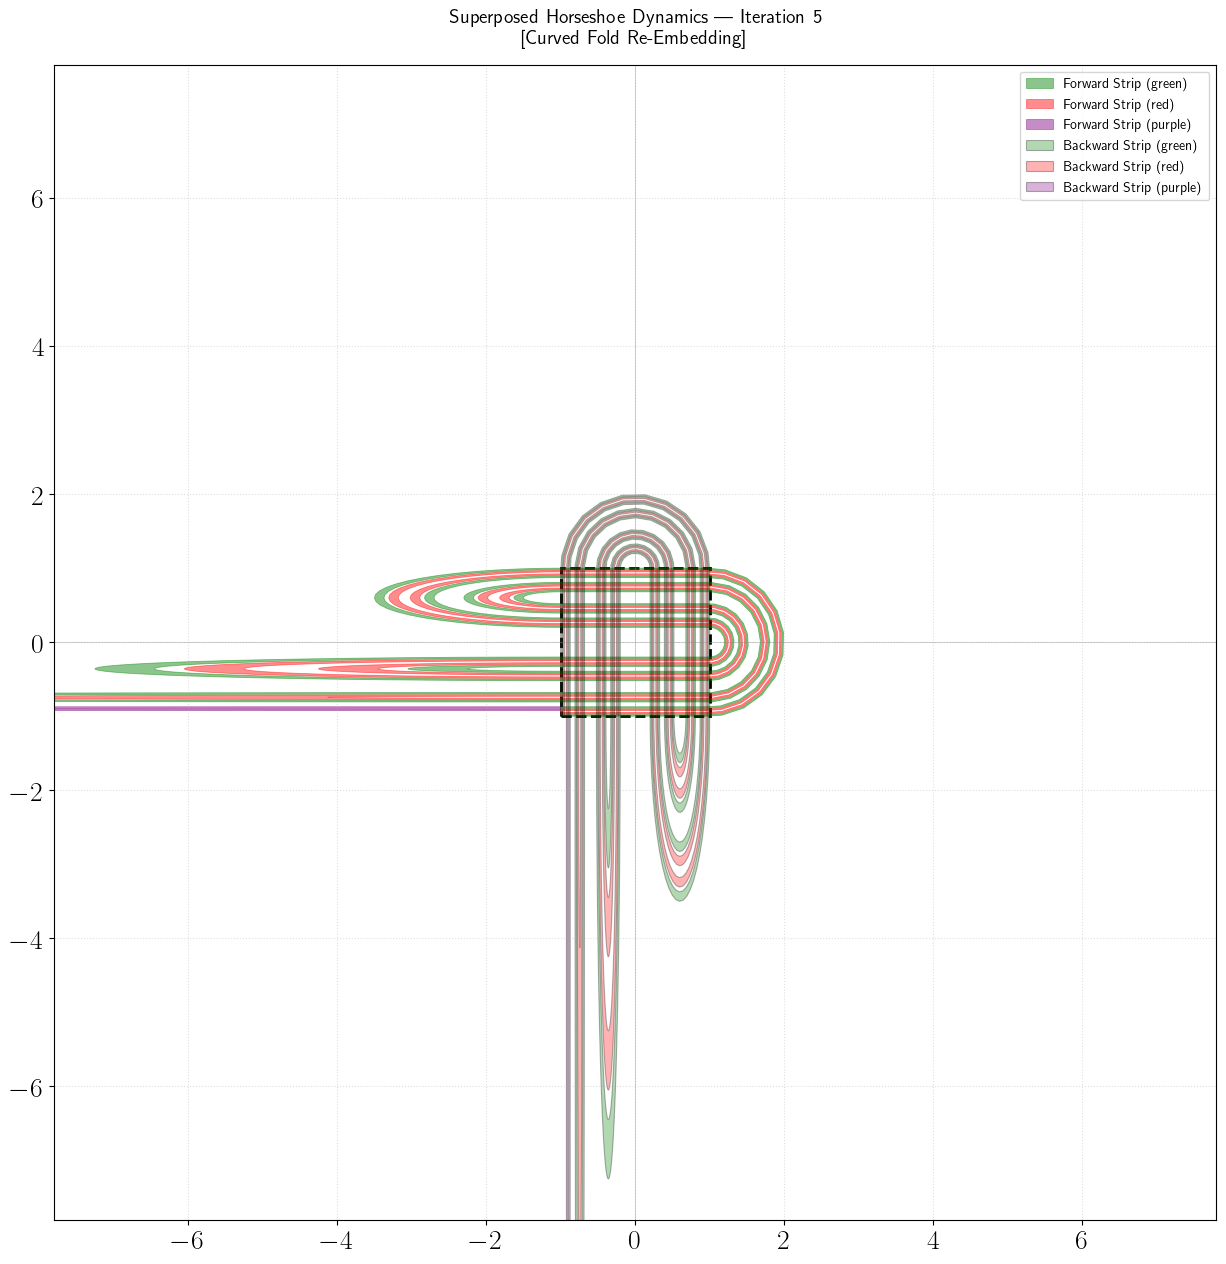

In [3]:
def plot_superposed_canvas(f_strips, b_strips, iteration_num, sub_step_name):
    fig, ax = plt.subplots(figsize=(15, 15))    
    ax.set_xlim(-7.8, 7.8)
    ax.set_ylim(-7.8, 7.8)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)      
    ax.add_patch(plt.Rectangle((-1, -1), 2, 2, edgecolor='black', facecolor='none', lw=2.0, ls='--'))
    for x, y, color in f_strips:
        ax.fill(x, y, color=color, alpha=0.45, edgecolor=color, lw=0.6, label=f"Forward Strip ({color})")        
    for x, y, color in b_strips:
        ax.fill(x, y, color=color, alpha=0.30, edgecolor='black', lw=0.8, ls='-', label=f"Backward Strip ({color})")
        
    ax.set_title(f"Superposed Horseshoe Dynamics — Iteration {iteration_num}\n[{sub_step_name}]", 
                 fontsize=14, fontweight='bold', pad=15)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=10)
    plt.show()

def run_deep_iterations(max_iterations=3):
    fx1, fy1 = create_points([-1, 1], [-0.2, 1], [-0.2, -1], [-1, -1])
    fx2, fy2 = create_points([0.2, 1], [1, 1], [1, -1], [0.2, -1])
    fx3, fy3 = create_points([-0.2, 1], [0.2, 1], [0.2, -1], [-0.2, -1])
    f_current = [[fx1, fy1, 'green'], [fx2, fy2, 'red'], [fx3, fy3, 'purple']]    
    
    bx1, by1 = create_points([1, -1], [1, -0.2], [-1, -0.2], [-1, -1])
    bx2, by2 = create_points([1, 1], [1, 0.2], [-1, 0.2], [-1, 1])
    bx3, by3 = create_points([1, -0.2], [1, 0.2], [-1, 0.2], [-1, -0.2])
    b_current = [[bx1, by1, 'green'], [bx2, by2, 'red'], [bx3, by3, 'purple']]
    
    clear_output(wait=True)
    plot_superposed_canvas(f_current, b_current, iteration_num=0, sub_step_name="Initial Base Configuration")
    time.sleep(0.5)
    
    f_matrix = [[2.5, 0.0], [0.0, 0.4]]
    b_matrix = [[0.4, 0.0], [0.0, 2.5]]
    anchor = np.array([-1.0, -1.0])

    for i in range(1, max_iterations + 1):
        f_text_stretched = []
        for x, y, color in f_current:
            sx, sy = apply_linear_stretch(x, y, f_matrix, about_point=anchor)
            f_text_stretched.append([sx, sy, color])
            
        b_text_stretched = []
        for x, y, color in b_current:
            sx, sy = apply_linear_stretch(x, y, b_matrix, about_point=anchor)
            b_text_stretched.append([sx, sy, color])
            
        clear_output(wait=True)
        plot_superposed_canvas(f_text_stretched, b_text_stretched, iteration_num=i, sub_step_name="Linear Matrix Stretching")
        time.sleep(2.0)
        
        f_current = []
        for x, y, color in f_text_stretched:
            fx, fy = f_map_to_circle(x, y)
            f_current.append([fx, fy, color])
            
        b_current = []
        for x, y, color in b_text_stretched:
            bx, by = b_map_to_circle(x, y)
            b_current.append([bx, by, color])
            
        clear_output(wait=True)
        plot_superposed_canvas(f_current, b_current, iteration_num=i, sub_step_name="Curved Fold Re-Embedding")
        time.sleep(2.5)




run_deep_iterations(max_iterations=5)

**12.1.7** (Smale horseshoe)                                                                                                                               
Figure 1 illustrates the mapping known as the Smale horseshoe (Smale 1967).                                                                                
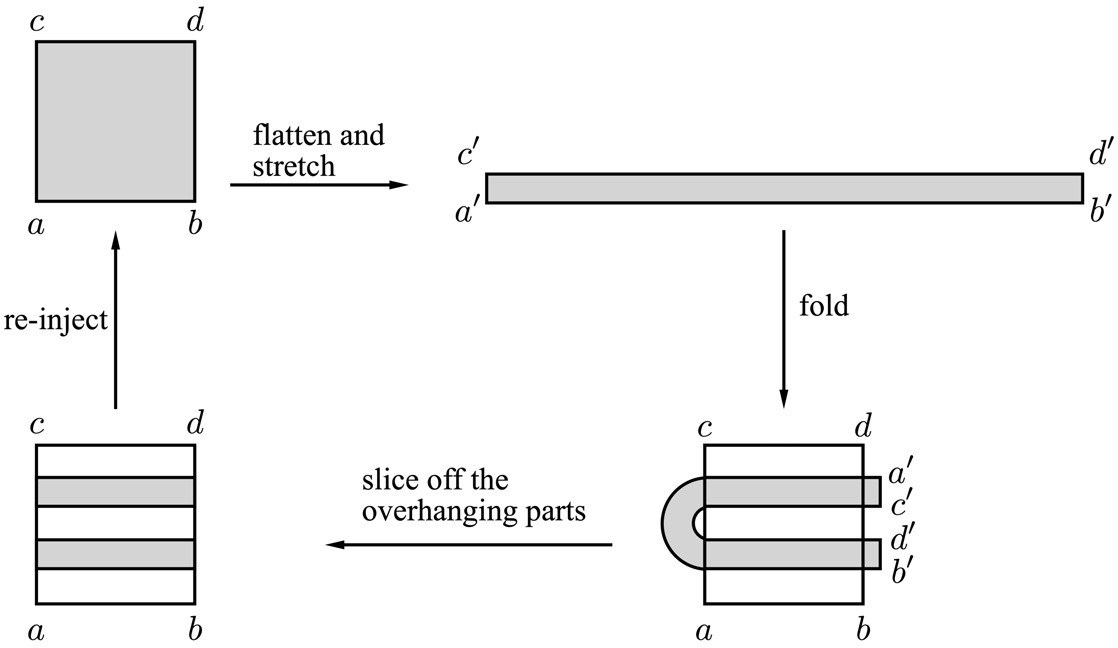

Notice the crucial difference between this map and that shown in Figure 12.1.3:                                                                          
here the horseshoe hangs over the edge of the original square.                                                                                            
The overhanging parts are lopped off before the next iteration proceeds.                                                                                      
a) The square at the lower left of Figure 1 contains two shaded horizontal strips.                                                                         
$\quad$Find the points in the original square that map to these strips.                                                                                         
$\quad$(These are the points that survive one iteration, in the sense that they still remain in the square.)                                                           
b) Show that after the next round of the mapping, the square on the lower left contains four horizontal strips.                                              
$\quad$Find where they came from in the original square.                                                                                                           
$\quad$(These are the points that survive two iterations.)                                                                                                            
c) Describe the set of points in the original square that survive forever.                                                                                 
$\quad$The horseshoe arises naturally in the analysis of transient chaos in differential equations.                                                                   
$\quad$Roughly speaking, the Poincaré map of such systems can often be approximated by the horseshoe.                                                                     
$\quad$During the time the orbit remains in a certain region corresponding to the square above, the stretching and folding of the map causes chaos.                                          
$\quad$However, almost all orbits get mapped out of this region eventually (into the “overhang”),                                                                    
$\quad$and then they escape to some distant part of phase space; this is why the chaos is only transient.                                                           
See Guckenheimer and Holmes (1983) or Arrowsmith and Place (1990) for introductions to the mathematics of horseshoes.

 
The series of steps defining the piece-wise map functions across different intervals are given by: 

$F(x, y) =  \begin{cases}  \begin{aligned} x' &= m x \\ y' &= h y \end{aligned}  \xrightarrow{y'' = y'}  \begin{aligned} x'' &= -x' \\ y'' &= y' + s_y \end{aligned} \xrightarrow{x''' = x''}  \begin{aligned} x''' &= x'' - s_x \\ y''' &= y'' \end{aligned} & \quad -1 \le x < 0 \\\\ \begin{aligned} x' &= m x \\ y' &= h y \end{aligned}  \xrightarrow{y'' = y'}  \begin{aligned} x'' &= x' \\ y'' &= y' - s_y \end{aligned} \xrightarrow{x''' = x''}  \begin{aligned} x''' &= x'' - s_x \\ y''' &= y'' \end{aligned} & \quad 0 \le x \le 1 \end{cases}$ 

Putting all the steps together, the combined forward map $F(x, y)$ is: 

$F(x, y) =  \begin{cases}  \begin{pmatrix} -m x - s_x \\ -h y + s_y \end{pmatrix} & -1 \le x < 0 \\\\ \begin{pmatrix} m x - s_x \\ h y - s_y \end{pmatrix} & 0 \le x \le 1 \end{cases}$ 


Restricting the Domain (Chopping Off Step)                                                                                                                  
To restrict the mapping to lie entirely inside the square rather than worrying about the original boundary constraints, we analyze the conditions:

$x_{n+1} = \pm m x_n - s_x \quad \text{and} \quad y_{n+1} = \pm h y_n \mp s_y$   

$1 \le x_{n+1}   = \pm mx_{n+1} - s_x \le 1$ 

$-1 \le m x_n - s_x \le 1 \quad \text{and} \quad -1 \le m x_n + s_x \le 1$ 

$\frac{-1 + s_x}{m} \le x_n \le \frac{1 + s_x}{m} \quad \text{and} \quad \frac{-1 - s_x}{m} \le x_n \le \frac{1 - s_x}{m}$ 


Based on this analysis, the only points that survive from the original square lie in two vertical strips. 

Explicit Inverse Map 

The inverse map functions are determined explicitly as: 

$x_n = \frac{\pm x_{n+1} + s_x}{m} \quad \text{and} \quad y_n = \frac{\pm y_{n+1} + s_y}{h}$ 

The parameter values chosen to ensure the map remains symmetrical are: 
* $m = 5$ 
* $h = \frac{1}{5}$ 
* $s_x = 2$ 
* $s_y = \frac{2}{5}$ 




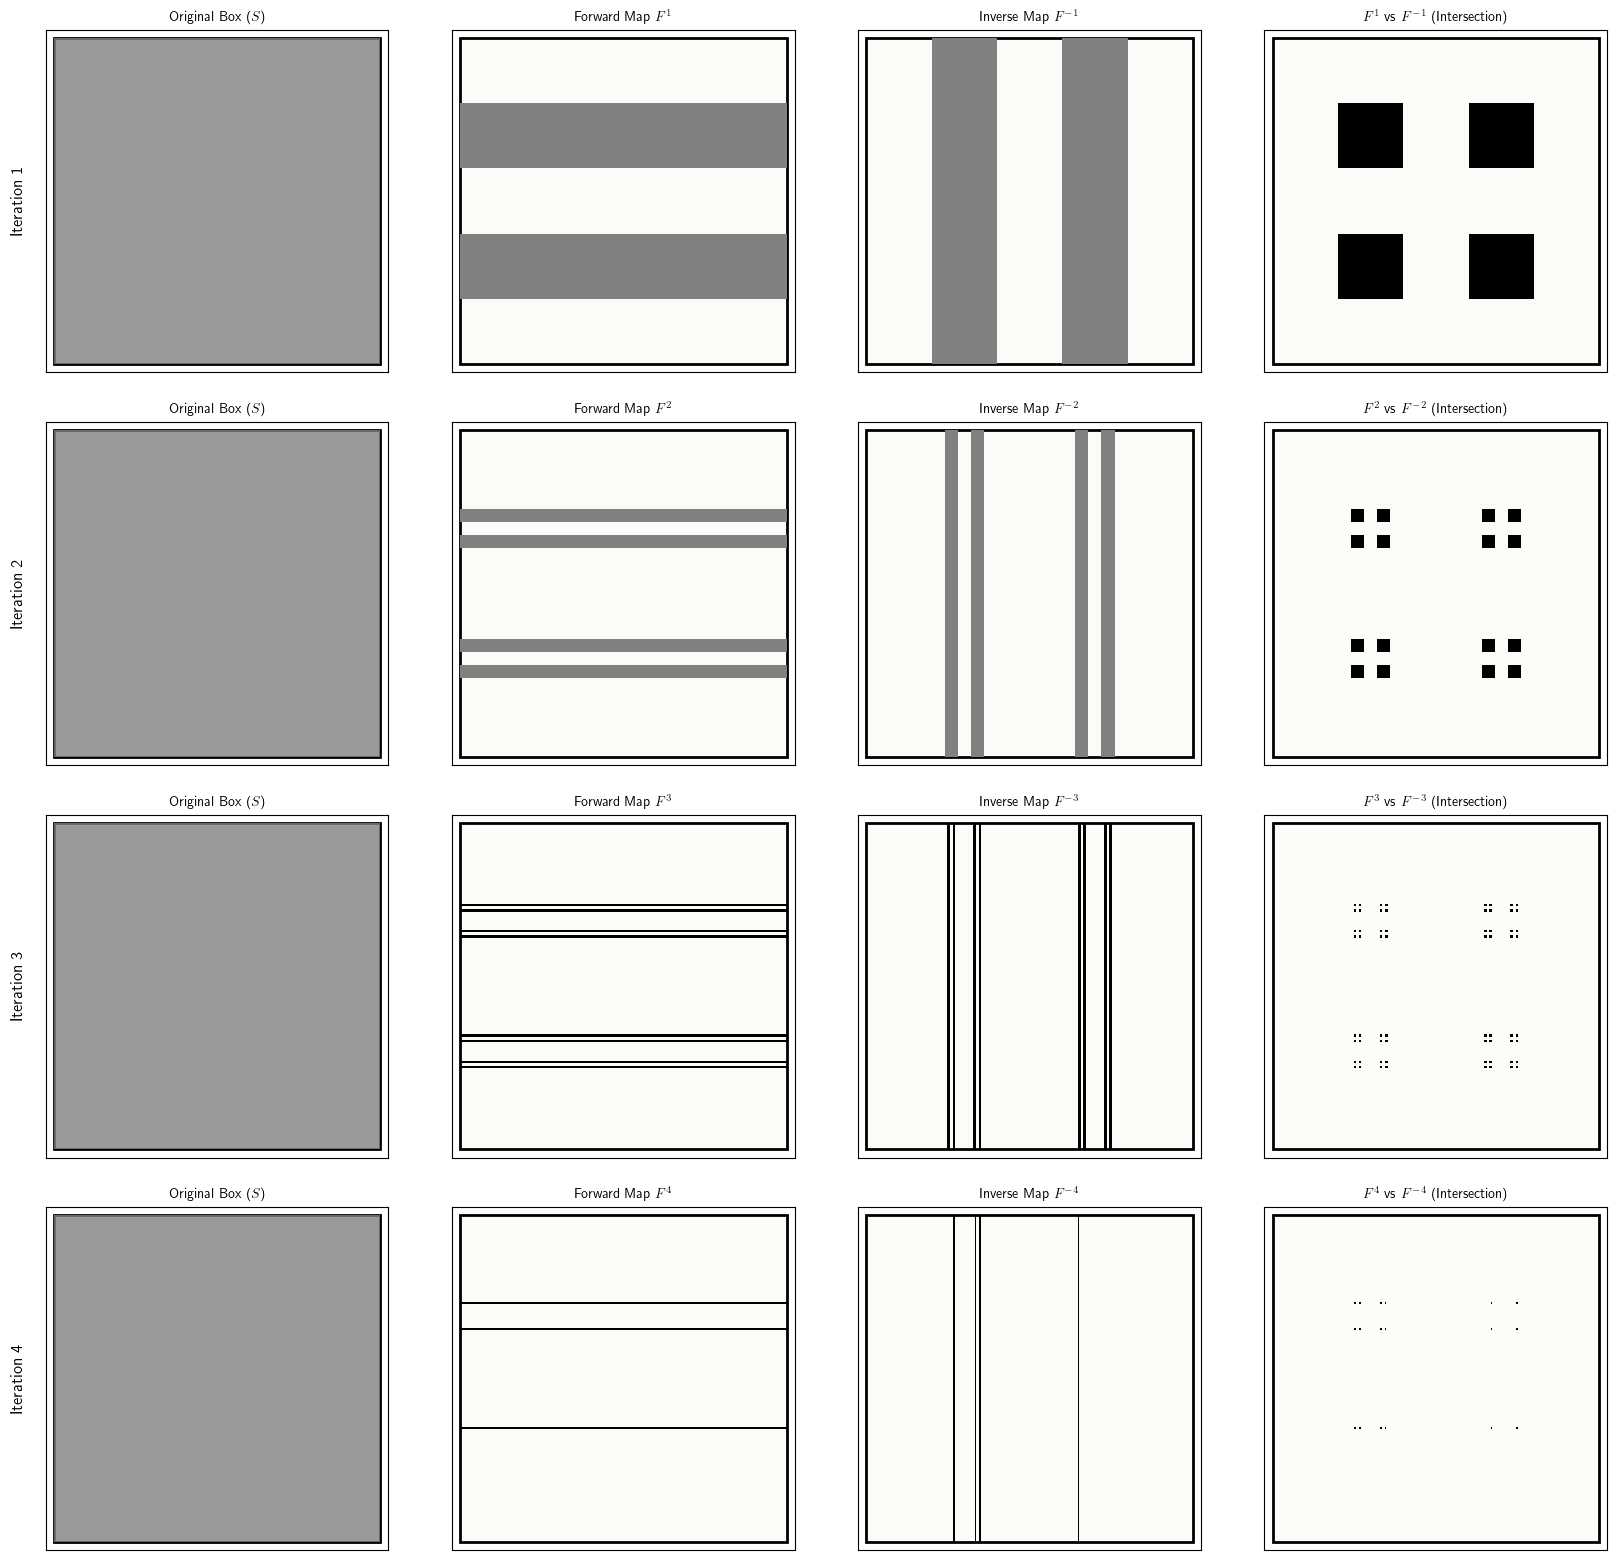

In [2]:
def strips(n, w=5.0, h=0.2, sx=2.0, sy=0.4):
    intervals = np.array([[-1.0, 1.0]])       
    for _ in range(n):
        next_intervals = []
        for low, high in intervals:
            h_new = (high - low) * h            
            lower_min = low * h - sy
            lower_max = lower_min + h_new
            next_intervals.append([lower_min, lower_max])            
            upper_min = low * h + sy
            upper_max = upper_min + h_new
            next_intervals.append([upper_min, upper_max])
        intervals = np.array(next_intervals)        
    intervals = intervals[np.argsort(intervals[:, 0])]
    return intervals

iterations = [1, 2, 3, 4]
fig, axes = plt.subplots(4, 4, figsize=(17, 16))   
for idx, n in enumerate(iterations):
    bands = strips(n)    
    for i in range(4):
        axes[idx, i].add_patch(plt.Rectangle((-1, -1), 2, 2, facecolor='#fbfcf7', edgecolor='black', lw=2))
        
    fill_color = 'gray' if n <= 2 else 'black'
    axes[idx, 0].add_patch(plt.Rectangle((-1, -1), 2, 2, facecolor='gray', edgecolor='none', alpha=0.8))
    axes[idx, 0].set_title("Original Box ($S$)", fontsize=10, fontweight='bold')
    axes[idx, 0] .set_ylabel(f"Iteration {n}", fontsize=12, fontweight='bold', labelpad=15)

    for y_min, y_max in bands:
        axes[idx, 1].add_patch(plt.Rectangle((-1, y_min), 2, y_max - y_min, facecolor=fill_color, edgecolor='none'))
    axes[idx, 1].set_title(f"Forward Map $F^{n}$", fontsize=10, fontweight='bold')

    for x_min, x_max in bands:
        axes[idx, 2].add_patch(plt.Rectangle((x_min, -1), x_max - x_min, 2, facecolor=fill_color, edgecolor='none'))
    axes[idx, 2].set_title(f"Inverse Map $F^{{-{n}}}$", fontsize=10, fontweight='bold')

    for x_min, x_max in bands:
        for y_min, y_max in bands:
            axes[idx, 3].add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, facecolor='black', edgecolor='none'))
    axes[idx, 3].set_title(f"$F^{n}$ vs $F^{{-{n}}}$ (Intersection)", fontsize=10, fontweight='bold')
    
    for i in range(4):
        axes[idx, i].set_xlim(-1.05, 1.05)
        axes[idx, i].set_ylim(-1.05, 1.05)
        axes[idx, i].set_aspect('equal')
        axes[idx, i].set_xticks([])
        axes[idx, i].set_yticks([])
        axes[idx, i].grid(True, linestyle=':', alpha=0.3, color='gray')

plt.tight_layout()
plt.show()

## $$\text{The Baker's Map}$$ 

$ \qquad \begin{equation*} (x_n, y_n) = \left\{\begin{array}{rl} (2x_n, ay_n) & \text{for } 0\le x_n\le \frac{1}{2},\\ (2x_n-1, ay_n+\frac{1}{2}) & \text{for } \frac{1}{2}\le x_n\le 1.\end{array} \right. \\ \qquad\qquad\text{where } 0<a\le\frac{1}{2} \end{equation*} $ 

In [22]:
def bakers_map(x,y, a):

    if 0 <= x <= 0.5:
        return 2 * x, a * y
    else:
        return 2 * x - 1, a * y + 0.5

In [23]:
def iterate_bakers_map(n, a, points):
    x_vals = [point[0] for point in points]
    y_vals = [point[1] for point in points]
    
    for _ in range(n):
        new_points = []
        for x, y in zip(x_vals, y_vals):
            x_new, y_new = bakers_map(x, y, a)
            new_points.append((x_new, y_new))
        x_vals, y_vals = zip(*new_points)
    return x_vals, y_vals

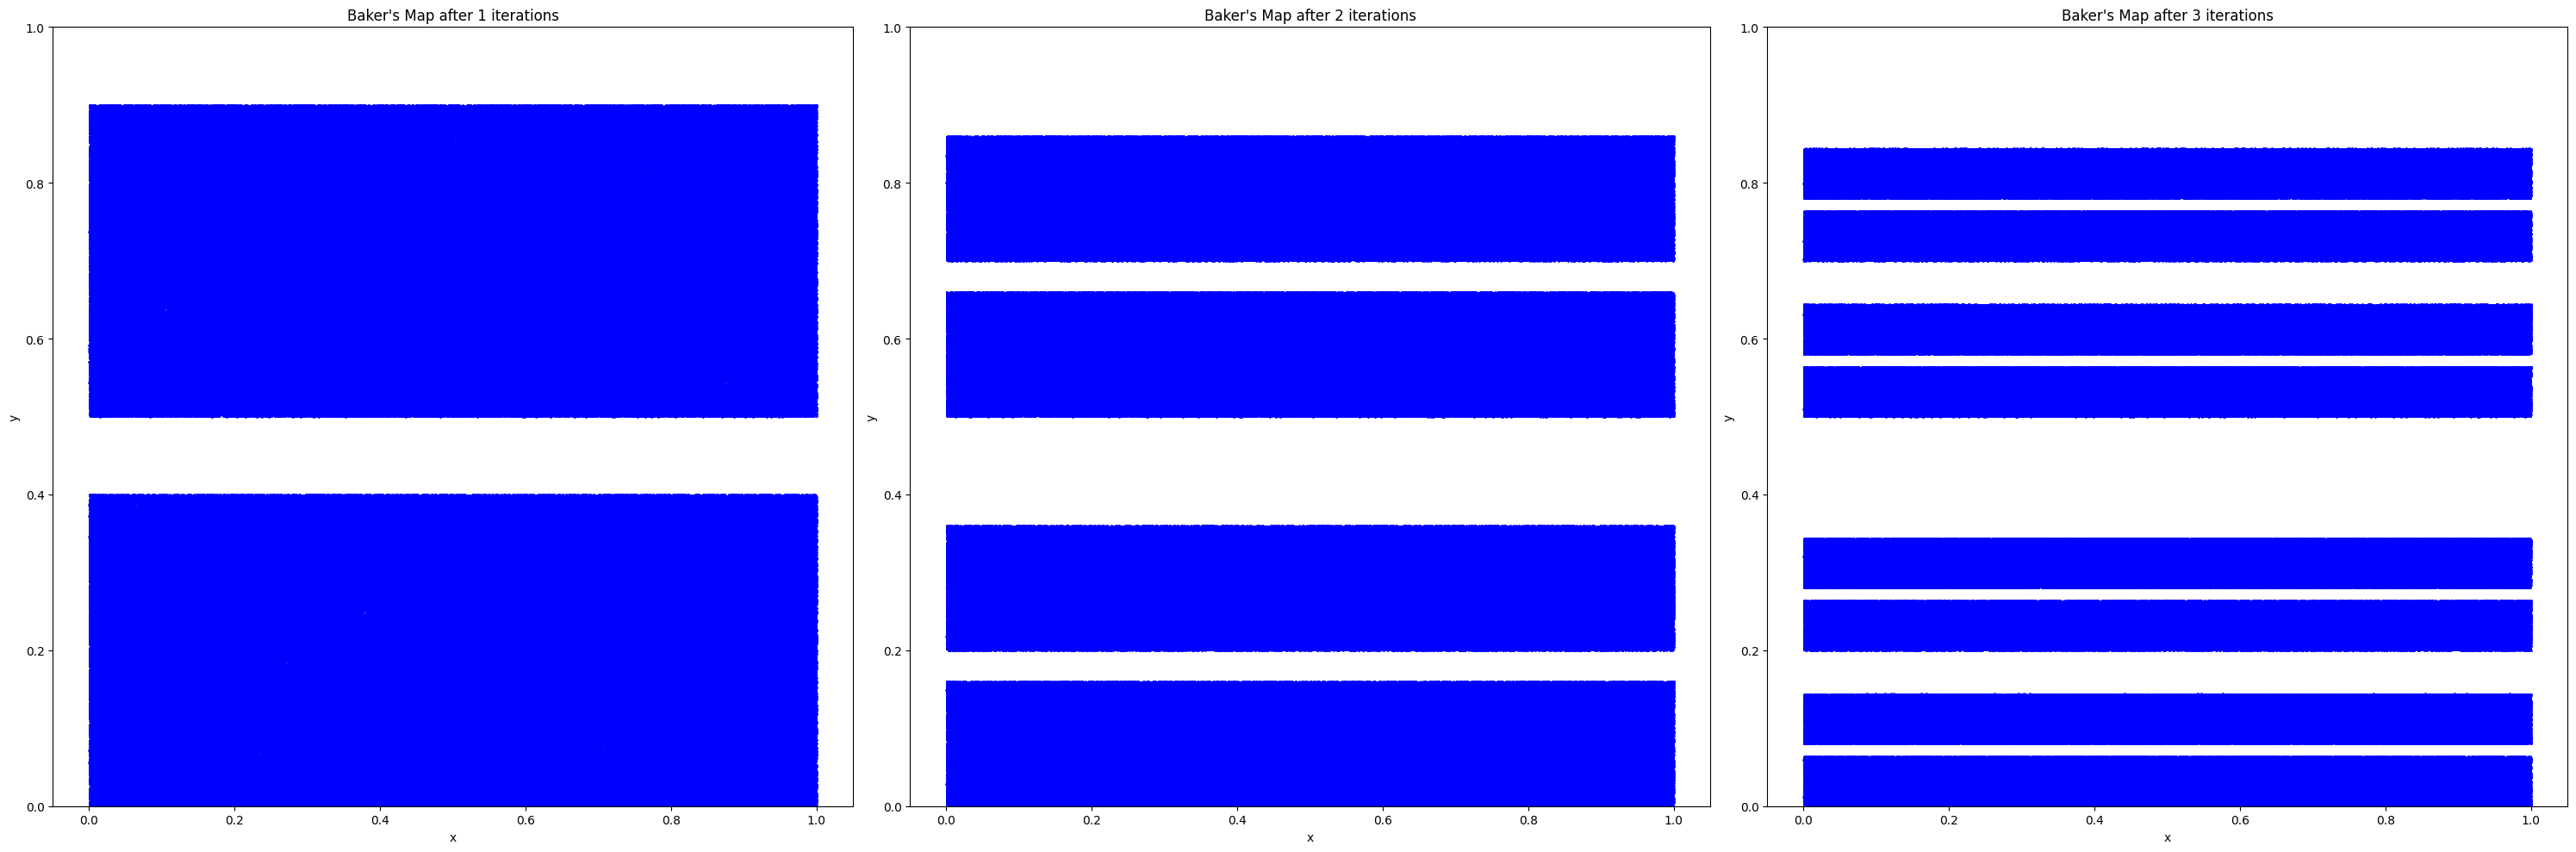

In [24]:
num_points = 1000000
points = np.random.rand(num_points, 2)
a = 0.4
iterations = [1,2,3]

fig, ax = plt.subplots(1, len(iterations), figsize=(30, 10))
for i, iterations in enumerate(iterations):
    x_vals, y_vals = iterate_bakers_map(iterations, a, points)
    ax[i].scatter(x_vals, y_vals, s=1, color='blue')
    ax[i].set_title("Baker's Map after {} iterations".format(iterations))
    ax[i].set_ylim(0,1)
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
plt.tight_layout()
plt.show()

**12.1.6** $\;$Study the baker’s map on a computer for the case $a = \frac{1}{2}.$                                                              
$\qquad\quad$Starting from a random initial condition, plot the first ten iterates and label them.

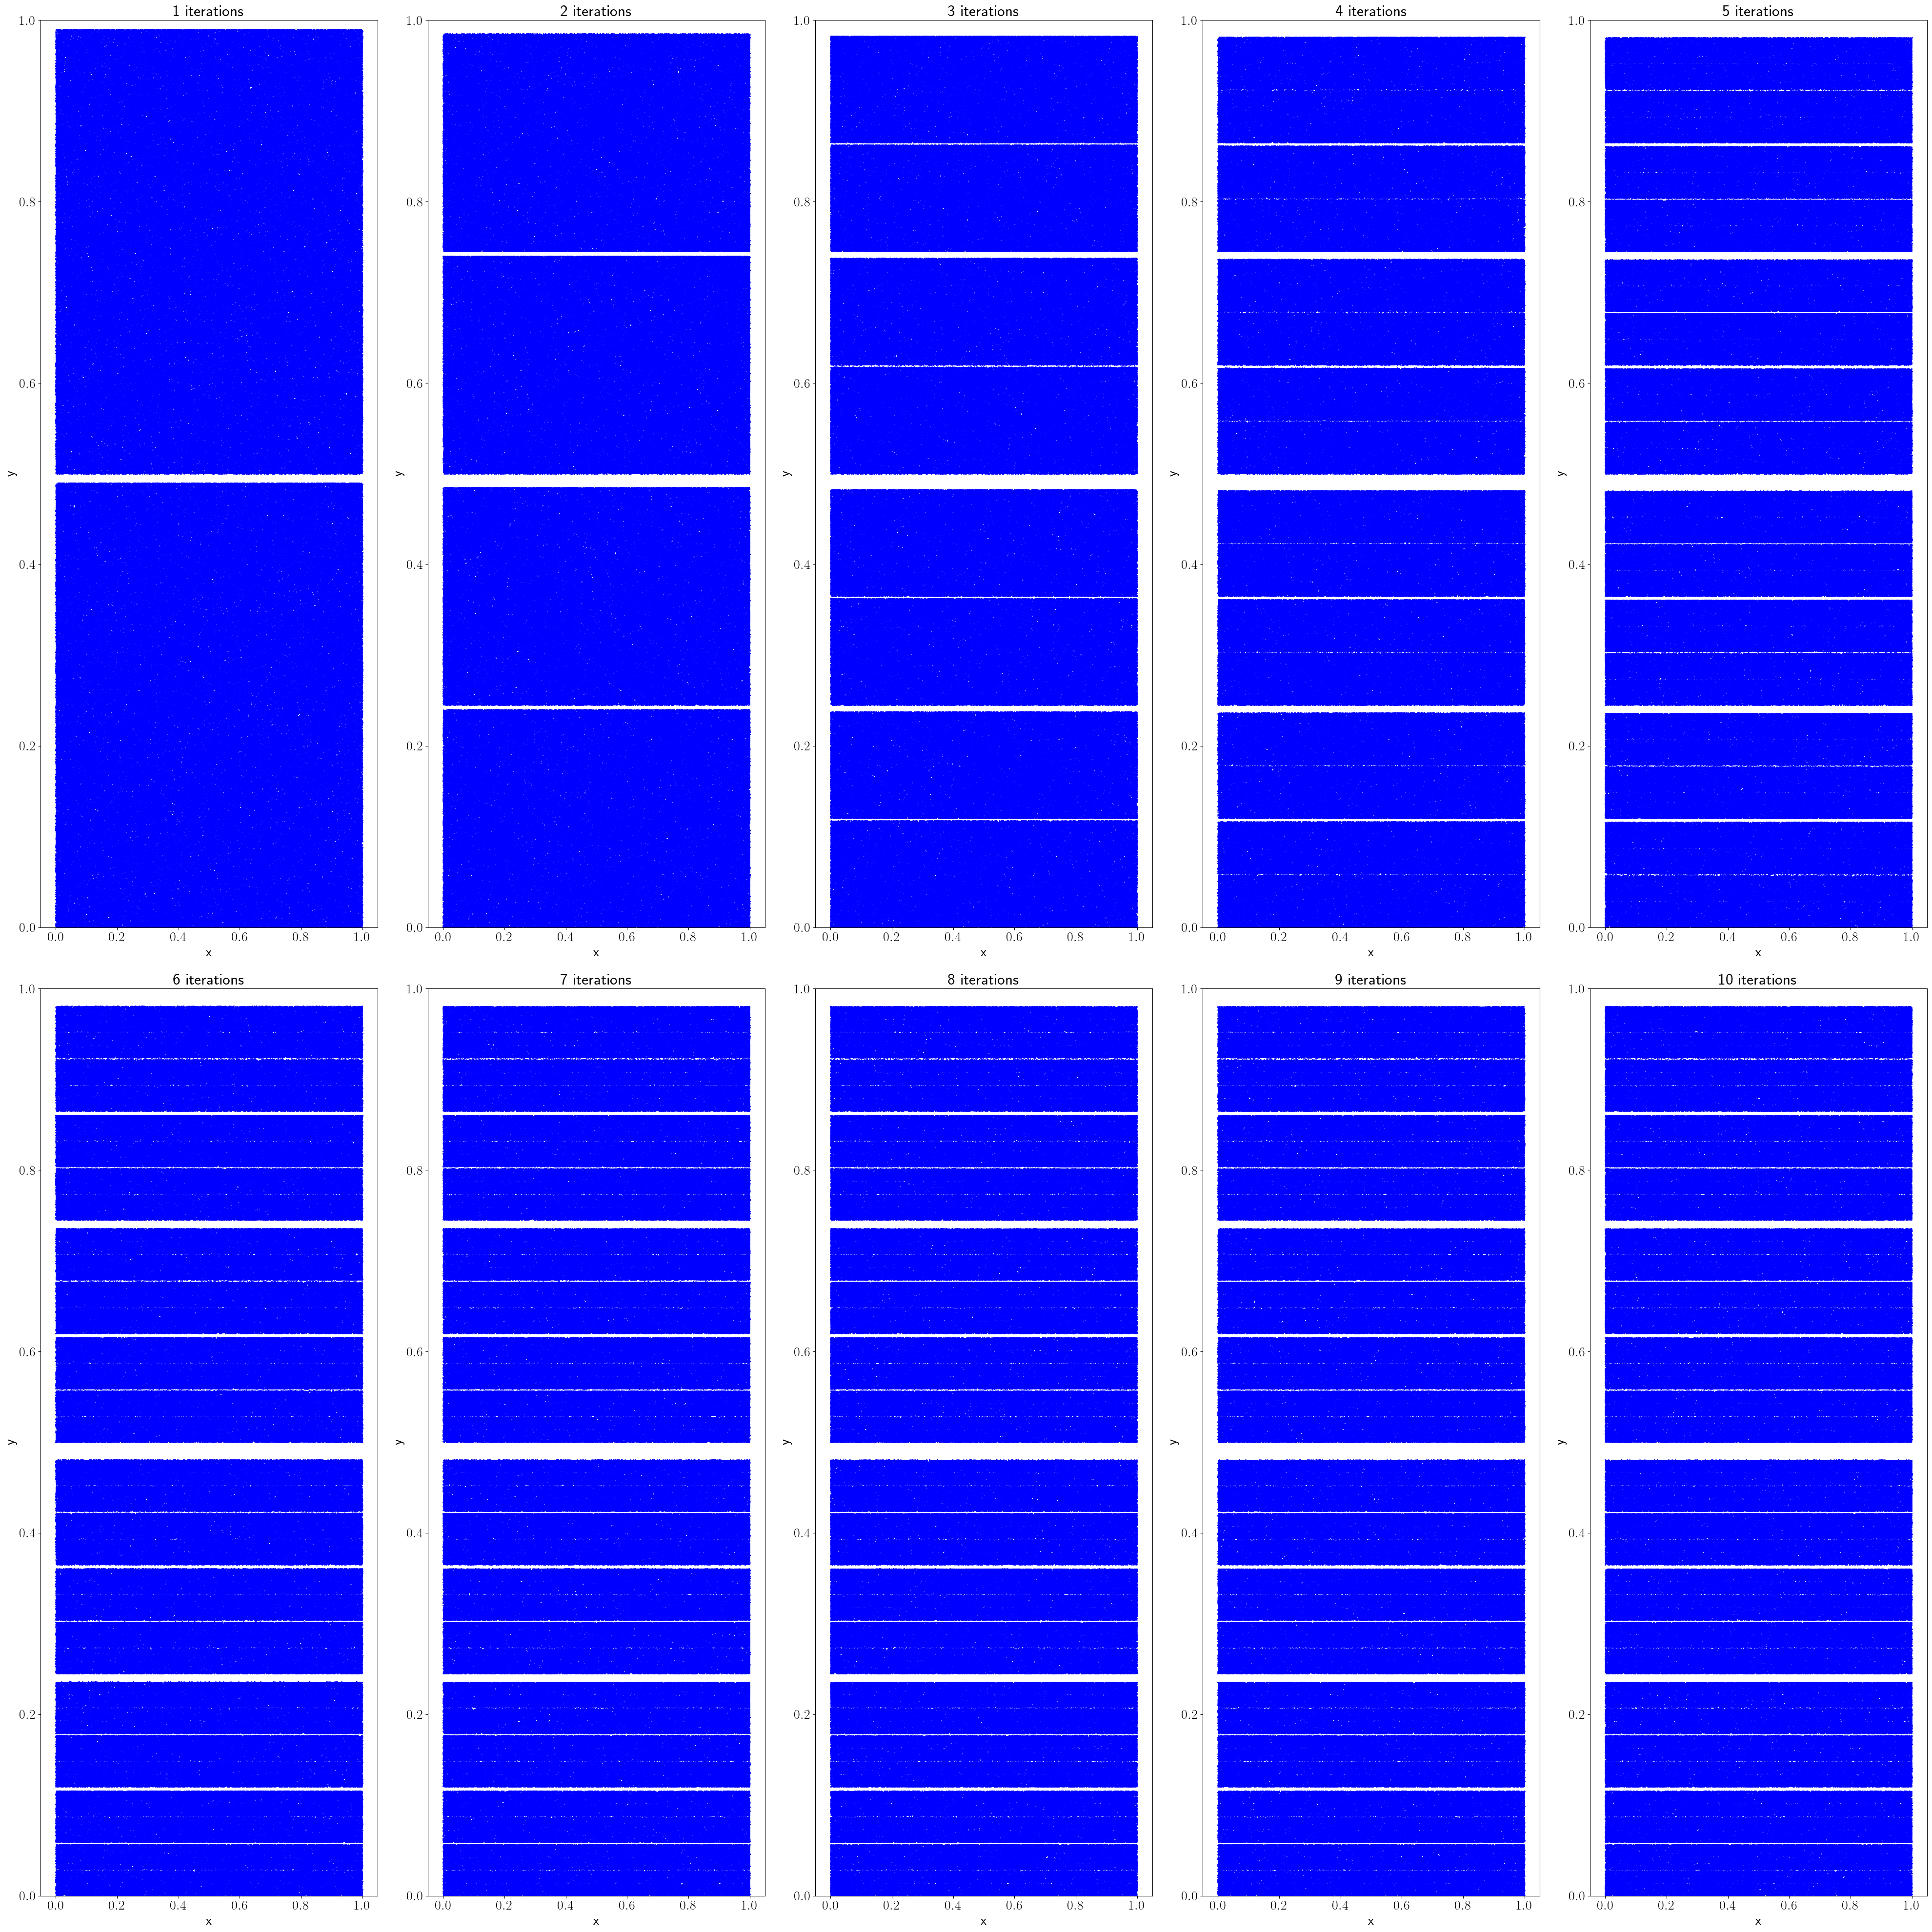

In [12]:
num_points = 1000000
points = np.random.rand(num_points, 2)
a = 0.49
iterations_list = [1,2,3,4,5,6,7,8,9,10]

fig, axes = plt.subplots(2, 5, figsize=(40, 40))
for i, iterations in enumerate(iterations_list):
    x_transformed, y_transformed = iterate_bakers_map(iterations, a, points)
    ax = axes[i // 5, i % 5]  # Access the correct subplot
    ax.scatter(x_transformed, y_transformed, s=1, color='blue')
    ax.set_title(f"{iterations} iterations")
    ax.set_ylim(0, 1)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [4]:
def lyapunov_exponent(point, delta=1e-8, a=0.4, num_steps=50):
    x1, y1 = point
    x2, y2 = x1 + delta, y1
    
    dist_sum = 0.0
    for _ in range(num_steps):
        x1, y1 = bakers_map(np.array([[x1, y1]]), a)[0]
        x2, y2 = bakers_map(np.array([[x2, y2]]), a)[0]
        
        d = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if d == 0: d = 1e-12  # prevent log(0)
        dist_sum += np.log(abs(d / delta))
        
        # Renormalize the separation
        dx, dy = x2 - x1, y2 - y1
        norm = np.sqrt(dx**2 + dy**2)
        x2, y2 = x1 + delta * dx / norm, y1 + delta * dy / norm
    
    return dist_sum / num_steps

# Example
lyap = lyapunov_exponent((0.1, 0.1), a=0.4)
print("Lyapunov exponent ≈", lyap)


Lyapunov exponent ≈ 0.693147182698124


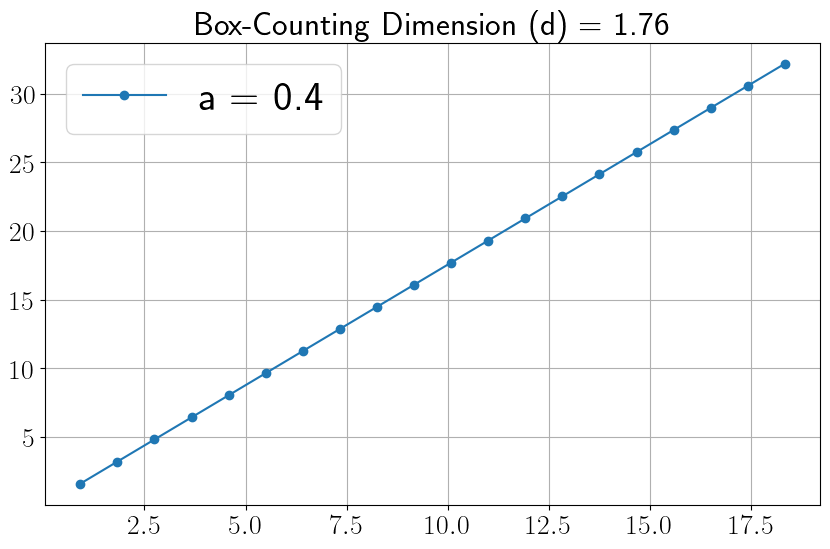

Calculated Box-Counting Dimension: 1.76


In [13]:
def calculate_box_counting_dimension(a, max_n):
    n_values = np.arange(1, max_n + 1)
    epsilon_values = a ** n_values
    N_values = (a / 2) ** (-n_values)
    
    log_epsilon = np.log(1 / epsilon_values)
    log_N = np.log(N_values)
    dimension = 1 + np.log(1 / 2) / np.log(a)   
    return n_values, log_epsilon, log_N, dimension


a = 0.4
max_n = 20
n_values, log_epsilon, log_N, dimension = calculate_box_counting_dimension(a, max_n)

plt.figure(figsize=(10, 6))
plt.plot(log_epsilon, log_N, 'o-', label=f'a = {a}')

plt.title(f'Box-Counting Dimension (d) = {dimension:.2f}')
plt.legend()
plt.grid(True)
plt.show()

print(f'Calculated Box-Counting Dimension: {dimension:.2f}')